In [1]:
from agent import Agent
from data.read_data import read_data
import numpy as np
import matplotlib.pyplot as plt

data_dict = read_data()
K, L, num_links, numm_agents, noise_covariance, timestep, initial_positions, target_positions = data_dict.values()

In [23]:
# Main simulation loop
configurations = [None, (Agent.FilterType.MovingAverage, {'window_size': 5}), (Agent.FilterType.MovingAverage, {'window_size': 10})]
error_history = np.zeros((K, len(configurations)), dtype=float)
for config_idx, config in enumerate(configurations):
    agents = [Agent(id, pos) for id, pos in enumerate(initial_positions)]
    for k in range(K):
        for i, agent in enumerate(agents):
            agent.measure(agents, noise_covariance, use_noise=True)
            if config is not None:
                # pass the config as a single argument (Agent.filter expects one arg besides self)
                agent.filter(config[0], **config[1])
            agent.update_position(L[i], timestep)
        
            error_history[k, config_idx] += np.linalg.norm(agent.position - target_positions[i]) ** 2
    



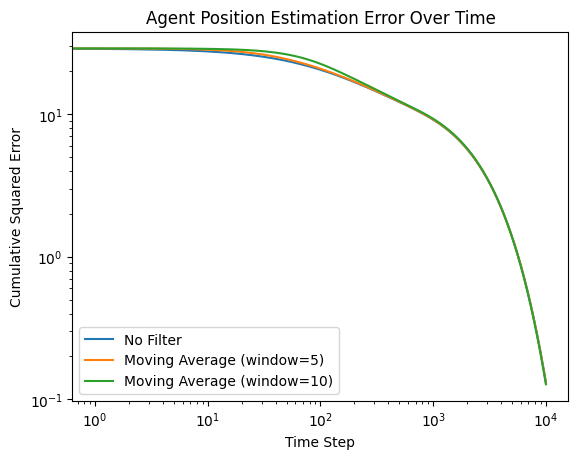

In [7]:
# Plotting the results
plt.figure()
for idx, config in enumerate(configurations):
    label = 'No Filter' if config is None else f'Moving Average (window={config[1]["window_size"]})'
    plt.plot(error_history[:, idx], label=label)
plt.xlabel('Time Step')
plt.ylabel('Cumulative Squared Error')
plt.legend()
plt.title('Agent Position Estimation Error Over Time')
plt.loglog()
plt.show()

[1. 1. 1.]


C:\Users\henlu\AppData\Local\Temp\ipykernel_38084\2925580376.py:7: RuntimeWarning: divide by zero encountered in power
  return a * (b / c) * (x / c) ** (b - 1) * np.exp(-(x / c) ** b)


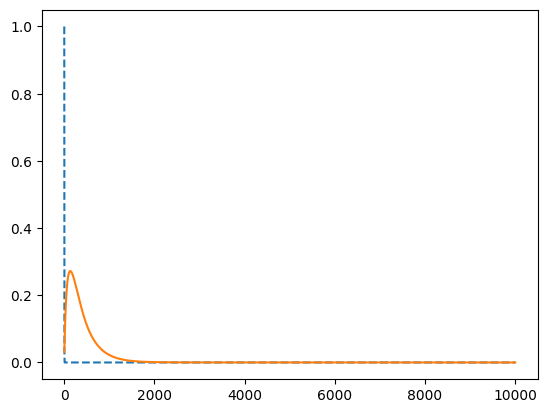

In [21]:
from scipy.optimize import curve_fit
import numpy as np
def model_func(x, a, b, c, d):
    return a * np.log(b * x + c) + d

def weibull_distribution(x, a, b, c):
    return a * (b / c) * (x / c) ** (b - 1) * np.exp(-(x / c) ** b)

for id in [6]: #range(3, len(initial_positions)):
    for other_id in [5]: #range(3, len(initial_positions) - 1):
        measurements = np.array([agents[id].measurement_history[i][other_id][0] for i in range(len(agents[0].measurement_history))])
        x_data = np.arange(len(measurements))
        
        try:
            popt, pcov = curve_fit(weibull_distribution, x_data, measurements)
        except RuntimeError:
            print(f"Could not fit curve for Agent {id} to Agent {other_id}")
            continue
        print(popt)
        plt.plot(weibull_distribution(x_data, *popt), label='Fitted Line', linestyle='--')
        plt.plot(measurements, label='Measurements')

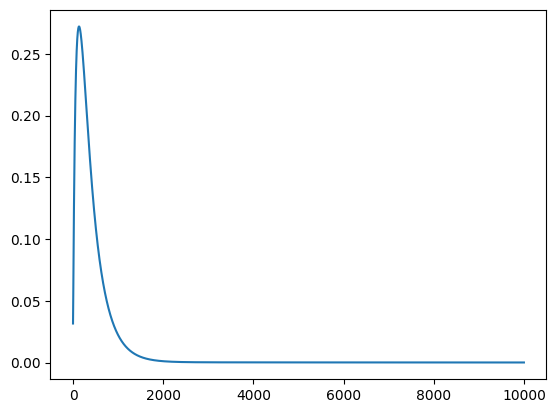

In [14]:
plt.plot([agents[6].measurement_history[i][5][0] for i in range(len(agents[0].measurement_history))], label='Measurements')

[]

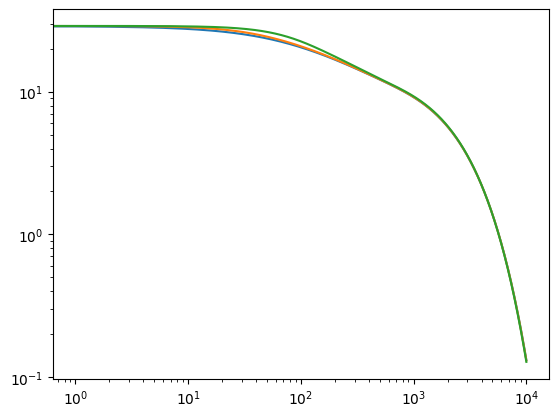

In [5]:
plt.plot(range(K), error_history)
plt.loglog()

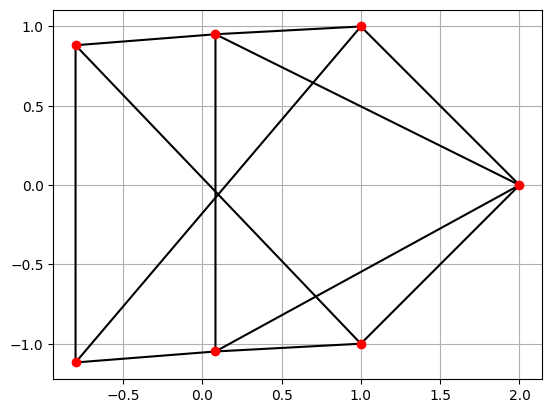

In [6]:
from plot_formation import plot_formation
plot_formation([agent.position_history[min(15000, len(agent.position_history)-1)] for agent in agents])